# 1. Import required libraries

This cell loads the tools used for file handling, data preparation, image transformations, model training, evaluation, and visualizations. It also checks whether a GPU is available and selects it when possible.

In [1]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import seaborn as sns

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU
Using device: cuda


# 2. Set project configuration

This cell defines the dataset location, image size, batch size, random seed, number of training epochs, and validation split. The random seed makes the data split and training setup more reproducible.

In [2]:
DATASET_DIR = r"D:\Hackathons\SIH KLE\Training"
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 40
VAL_SPLIT = 0.2

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# 3. Verify dataset folders

This cell lists the folders inside the dataset directory. Each folder should represent one waste category.

In [3]:
import os
print(os.listdir(DATASET_DIR))

['cardboard', 'Food Organics', 'glass', 'metal', 'paper', 'plastic', 'Textile Trash', 'Vegetation']


# 4. Check for corrupted images

This cell scans all supported image files in the dataset and reports any files that cannot be opened correctly. Corrupted images can otherwise interrupt training.

In [4]:
from PIL import Image
import os

def find_corrupted_images(root_dir):
    corrupted = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                fpath = os.path.join(dirpath, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()
                except Exception as e:
                    corrupted.append((fpath, str(e)))
    return corrupted

corrupted_files = find_corrupted_images(DATASET_DIR)
print(f"Found {len(corrupted_files)} corrupted images:")
for path, err in corrupted_files:
    print(f"  {path} — {err}")

Found 0 corrupted images:


# 5. Define image preprocessing and augmentation

This cell creates two image-processing pipelines. Training images receive random changes such as cropping, flipping, rotation, and colour adjustment to help the model generalize. Validation images receive consistent resizing only. Both are normalized for the pretrained ResNet model.

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 6. Load the dataset and create train/validation sets

This cell reads images from the category folders, identifies the class names, and creates an 80% training set and 20% validation set using a fixed random split.

In [8]:
base_dataset = datasets.ImageFolder(DATASET_DIR)
class_names = base_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("num_classes =", num_classes)
assert num_classes > 1, "num_classes must be > 1 — check DATASET_DIR and folder structure!"

n_total = len(base_dataset)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx = random_split(range(n_total), [n_train, n_val], generator=generator)

train_dataset_full = datasets.ImageFolder(DATASET_DIR, transform=train_transform)
val_dataset_full = datasets.ImageFolder(DATASET_DIR, transform=val_transform)

train_dataset = Subset(train_dataset_full, train_idx.indices)
val_dataset = Subset(val_dataset_full, val_idx.indices)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")

Classes: ['Food Organics', 'Textile Trash', 'Vegetation', 'cardboard', 'glass', 'metal', 'paper', 'plastic']
num_classes = 8
Train: 10418  Val: 2604


# 7. Create data loaders

This cell wraps the training and validation datasets into loaders that provide images in batches. Training batches are shuffled; validation batches keep a fixed order.

In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# 8. Calculate class weights

This cell counts images in each category and creates inverse-frequency weights. These weights make mistakes on smaller classes matter more during training, helping reduce class imbalance.

In [10]:
from collections import Counter

label_counts = Counter(label for _, label in base_dataset.samples)
class_counts = torch.tensor([label_counts[i] for i in range(num_classes)], dtype=torch.float)

print("Per-class counts:")
for name, count in zip(class_names, class_counts.tolist()):
    print(f"  {name}: {int(count)}")

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(device)

Per-class counts:
  Food Organics: 1040
  Textile Trash: 1341
  Vegetation: 486
  cardboard: 1758
  glass: 1617
  metal: 2150
  paper: 2031
  plastic: 2599


# 9. Build the ResNet-18 classification model

This cell loads ResNet-18 pretrained on ImageNet. It freezes the pretrained feature extractor and replaces the final layer with a new classifier for the eight waste categories.

In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes),
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 133384


# 10. Choose loss function, optimizer, and learning-rate scheduler

This cell defines how model errors are measured, how the trainable parameters are updated, and how the learning rate is reduced when validation loss stops improving.

In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 11. Define one training or validation pass

This function processes every batch in a loader and returns average loss and accuracy. In training mode it updates model weights; in validation mode it only measures performance.

In [13]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train_mode:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return running_loss / total, running_correct / total

# 12. Phase 1: train the new classifier head

This cell trains only the newly added classification head while keeping pretrained layers frozen. It saves the best model based on validation loss and stops early if performance does not improve.

In [19]:
EPOCHS = 50

history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, "best_waste_model_v2.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)
print(f"Phase 1 complete. Best val_loss: {best_val_loss:.4f}")

KeyboardInterrupt: 

# 13. Prepare Phase 2 fine-tuning

This cell unfreezes the full ResNet model so all layers can adapt to the waste dataset. It uses a much smaller learning rate to preserve useful pretrained features.

In [14]:
# Unfreeze the entire backbone for fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Much smaller learning rate — critical for fine-tuning without destroying
# the pretrained features
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 11309896


# 14. Phase 2: fine-tune the complete model

This cell trains the fully unfrozen model, tracks metrics, saves the best weights based on validation loss, and restores those best weights after training.

In [14]:
EPOCHS = 30

history_p2 = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history_p2["loss"].append(train_loss)
    history_p2["accuracy"].append(train_acc)
    history_p2["val_loss"].append(val_loss)
    history_p2["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, "best_waste_model_v2_phase2.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)
print(f"Phase 2 complete. Best val_loss: {best_val_loss:.4f}")

Epoch 1/30 - loss: 1.5914 - acc: 0.4444 - val_loss: 1.0511 - val_acc: 0.6770
Epoch 2/30 - loss: 0.9133 - acc: 0.6868 - val_loss: 0.6651 - val_acc: 0.7673
Epoch 3/30 - loss: 0.6552 - acc: 0.7613 - val_loss: 0.5113 - val_acc: 0.8191
Epoch 4/30 - loss: 0.5126 - acc: 0.8154 - val_loss: 0.4168 - val_acc: 0.8548
Epoch 5/30 - loss: 0.4263 - acc: 0.8446 - val_loss: 0.3543 - val_acc: 0.8725
Epoch 6/30 - loss: 0.3650 - acc: 0.8678 - val_loss: 0.3119 - val_acc: 0.8890
Epoch 7/30 - loss: 0.3160 - acc: 0.8865 - val_loss: 0.3015 - val_acc: 0.8940
Epoch 8/30 - loss: 0.2714 - acc: 0.9015 - val_loss: 0.2703 - val_acc: 0.9021
Epoch 9/30 - loss: 0.2370 - acc: 0.9175 - val_loss: 0.2637 - val_acc: 0.9078
Epoch 10/30 - loss: 0.2207 - acc: 0.9197 - val_loss: 0.2575 - val_acc: 0.9113
Epoch 11/30 - loss: 0.1904 - acc: 0.9335 - val_loss: 0.2407 - val_acc: 0.9228
Epoch 12/30 - loss: 0.1797 - acc: 0.9386 - val_loss: 0.2282 - val_acc: 0.9236
Epoch 13/30 - loss: 0.1509 - acc: 0.9463 - val_loss: 0.2231 - val_acc: 0.

# 15. Restore the best Phase 2 model weights

This cell is a safety check that saves the latest improved model, when applicable, then loads the best saved weights. The ellipsis is only a placeholder and can be removed.

In [15]:
if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_weights = copy.deepcopy(model.state_dict())
    torch.save(best_weights, "best_waste_model_v2_phase2.pt")
    ...
model.load_state_dict(best_weights)  # restores best epoch's weights before moving on

NameError: name 'val_loss' is not defined

# 16. Plot Phase 2 learning curves

This cell plots training versus validation accuracy and loss during fine-tuning. These charts help show whether the model is learning well or overfitting.

NameError: name 'history_p2' is not defined

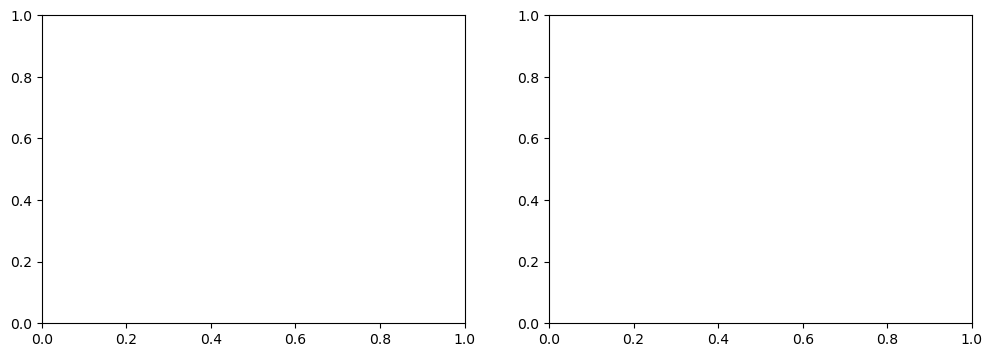

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history_p2["accuracy"], label="train")
ax[0].plot(history_p2["val_accuracy"], label="val")
ax[0].set_title("Accuracy (Phase 2)")
ax[0].legend()

ax[1].plot(history_p2["loss"], label="train")
ax[1].plot(history_p2["val_loss"], label="val")
ax[1].set_title("Loss (Phase 2)")
ax[1].legend()

plt.tight_layout()
plt.show()

# 17. Save Phase 2 training history

This cell saves the Phase 2 metric history to a file so the learning curves and results can be reused later.

In [17]:
import pickle
with open("history_p2.pkl", "wb") as f:
    pickle.dump(history_p2, f)

NameError: name 'history_p2' is not defined

# 18. Plot Phase 1 learning curves

This cell plots training versus validation accuracy and loss from the first training phase. It requires the history variable created by the Phase 1 training cell.

NameError: name 'history' is not defined

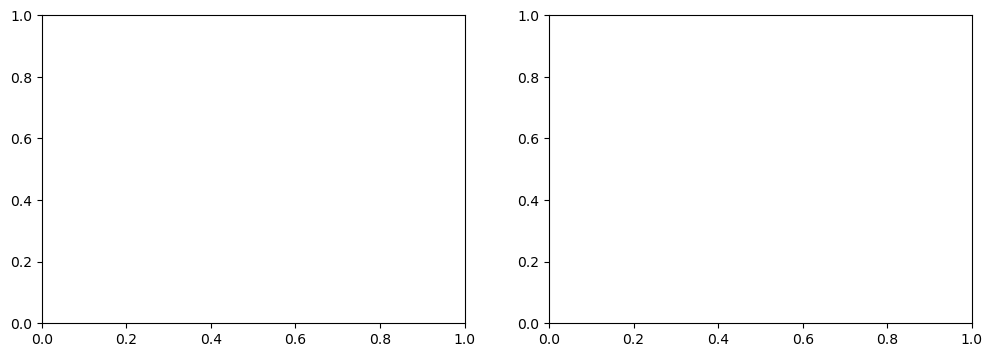

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["accuracy"], label="train")
ax[0].plot(history["val_accuracy"], label="val")
ax[0].set_title("Accuracy")
ax[0].legend()

ax[1].plot(history["loss"], label="train")
ax[1].plot(history["val_loss"], label="val")
ax[1].set_title("Loss")
ax[1].legend()

plt.tight_layout()
plt.show()


# 19. Evaluate the final model

This cell predicts the validation set, prints precision, recall, F1-score, and overall accuracy for every category, then draws a confusion matrix to show which categories are confused with each other.

               precision    recall  f1-score   support

Food Organics       0.94      0.93      0.93       206
Textile Trash       0.97      0.95      0.96       262
   Vegetation       0.95      0.94      0.95       111
    cardboard       0.97      0.97      0.97       376
        glass       0.94      0.94      0.94       314
        metal       0.95      0.95      0.95       411
        paper       0.97      0.96      0.96       410
      plastic       0.91      0.94      0.93       514

     accuracy                           0.95      2604
    macro avg       0.95      0.95      0.95      2604
 weighted avg       0.95      0.95      0.95      2604



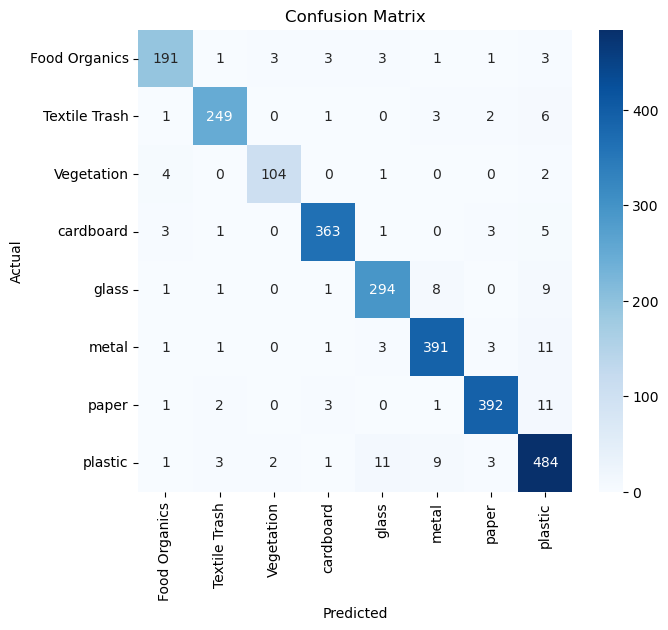

In [26]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [29]:
import torch

MODEL_PATH = r"C:\Users\HP\SIH KLE\best_waste_model_v2_phase2.pt"

# At the end of Phase 2, model already contains the best saved weights
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved successfully at:\n{MODEL_PATH}")

Model saved successfully at:
C:\Users\HP\SIH KLE\best_waste_model_v2_phase2.pt


# 20. Predict one new image

This cell defines a helper function that classifies a single image and returns its predicted waste category and confidence score. The final lines demonstrate it with one vegetation image.

In [44]:
import os
import torch
from PIL import Image

# Load the trained weights after every kernel restart
CHECKPOINT_PATH = r"C:\Users\HP\SIH KLE\best_waste_model.pth"

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Model file not found: {CHECKPOINT_PATH}\n"
        r"C:\Users\HP\SIH KLE\best_waste_model.pth"
    )

model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
)
model = model.to(device)
model.eval()

def predict_waste(img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        idx = probs.argmax().item()

    return class_names[idx], probs[idx].item()

test_image = r"C:\Users\HP\Pictures\Screenshots\Old SS\Screenshot 2026-08-21 112942.png"

label, confidence = predict_waste(test_image)
print(f"Predicted: {label} ({confidence * 100:.2f}% confidence)")

Predicted: Textile Trash (95.52% confidence)
